# Ancient Papyrus Daiqiry Data Extraction Script
This notebook is used to extract from .h5 file 1D serial XRD scan to .xy file for TOPAS software. The extraction is not one-click button. It is recommended that the user have a look first at the .h5 file architecture through Silx. Each cell of the notebook will allow the user to access the folder slowly, allowing the user to choose which folder, sample, dataset, scan number of interest. Inspection is possible at each step. 

## Notebook to Extract Processed 1D-XRD Scan

In [20]:
# load necessary packages
import numpy as np
import os
import h5py
from pathlib import Path
import matplotlib.pyplot as plt
import glob

We start with parent folder PROCESSED_DATA. First, have a look at all the sample folder we have here and choose which one you would like to proceed. 

In [21]:
# define parent folder file
folderpath = "/data/visitor/ihhg69/id13/20260409/PROCESSED_DATA/"
folder = Path(folderpath)
for f in folder.iterdir():
    print(f.name)

dq_pap163
dq_pap217
workflows
pap163
pap217
dq_modernpap
__CALIB
dq_al2o3
siemens
modernpap
al2o3


Here, folders with "dq_xxx" is acquisited using daiquiri user interface and folders without "dq_xxx" is tested measurements (for radiation damage eg) using BLISS cmd. <br>
Choose your interest sample folder below (just copy and paste)

In [22]:
sample_folder_name = "dq_pap217"
sample_folder = os.path.join(folderpath,sample_folder_name)
for f in Path(sample_folder).iterdir():
    print(f.name)

dq_pap217_roi146602_164526
dq_pap217_roi146601_164525
dq_pap217_roi146599_164523
dq_pap217_roi146600_164524
dq_pap217_roi146603_164528
dq_pap217_roi146597_164520
dq_pap217_roi146598_164522
dq_pap217_roi146596_164519


Then choose your dataset (look at your experiment note to see which one is interesting)

In [23]:
dataset_folder_name = "dq_pap217_roi146597_164520"
dataset_folder = os.path.join(sample_folder, dataset_folder_name)
for f in Path(dataset_folder).iterdir():
    print(f.name)

workflows
gallery
dq_pap217_roi146597_164520.h5


In [24]:
scan_path_name = dataset_folder_name
scan_path = os.path.join(dataset_folder, scan_path_name + ".h5")
with h5py.File(scan_path, 'r') as f:
    def print_tree(name, obj):
        print(name)

    f.visititems(print_tree)

1.1
1.1/eiger_average
1.1/eiger_average/average
1.1/eiger_average/average/2th
1.1/eiger_average/average/average_intensity
1.1/eiger_average/average/reference_alpha_Al2O3
1.1/eiger_average/name
1.1/eiger_diffmap
1.1/eiger_diffmap/configuration
1.1/eiger_diffmap/configuration/data
1.1/eiger_diffmap/configuration/type
1.1/eiger_diffmap/diffmap
1.1/eiger_diffmap/diffmap/2th
1.1/eiger_diffmap/diffmap/ct34
1.1/eiger_diffmap/diffmap/dark_value
1.1/eiger_diffmap/diffmap/intensity
1.1/eiger_diffmap/diffmap/intensity_norm
1.1/eiger_diffmap/diffmap/map
1.1/eiger_diffmap/diffmap/map_norm
1.1/eiger_diffmap/diffmap/xpoints
1.1/eiger_diffmap/diffmap/ypoints
1.1/eiger_diffmap/dim0
1.1/eiger_diffmap/dim1
1.1/eiger_diffmap/dim2
1.1/eiger_diffmap/mask_file
1.1/eiger_diffmap/name
1.1/eiger_diffmap/offset
1.1/eiger_integrate
1.1/eiger_integrate/configuration
1.1/eiger_integrate/configuration/data
1.1/eiger_integrate/configuration/type
1.1/eiger_integrate/integrated
1.1/eiger_integrate/integrated/2th
1.1/ei

In [25]:
twotheta_path = f"/1.1/eiger_integrate/integrated/2th"
intensity_path = f"/1.1/eiger_integrate/integrated/intensity"

with h5py.File(scan_path, 'r') as f:
    x = f[twotheta_path][:]
    y = f[intensity_path][:]

In [26]:
print("Two theta:", x)
print("Intensity:", y)

Two theta: [2.00000024e-02 6.00000072e-02 1.00000012e-01 ... 4.19000050e+01
 4.19400050e+01 4.19800050e+01]
Intensity: [[0.         0.         0.         ... 1.0067369  0.93749154 0.8014109 ]
 [0.         0.         0.         ... 0.9699357  0.8541163  0.96181434]
 [0.         0.         0.         ... 0.8100292  0.82539594 0.8971081 ]
 ...
 [0.         0.         0.         ... 1.0405357  0.99752927 1.1129764 ]
 [0.         0.         0.         ... 1.182969   1.1726794  1.0691208 ]
 [0.         0.         0.         ... 1.1810592  0.95401686 1.1129566 ]]


In [30]:
y_inspect = np.mean([
    y[9560, :]
], axis=0)
y_inspect

array([0.       , 0.       , 0.       , ..., 2.1392944, 2.311393 ,
       2.333194 ], dtype=float32)

Inspection on the data we want to acquire by plotting them :D (the best way)

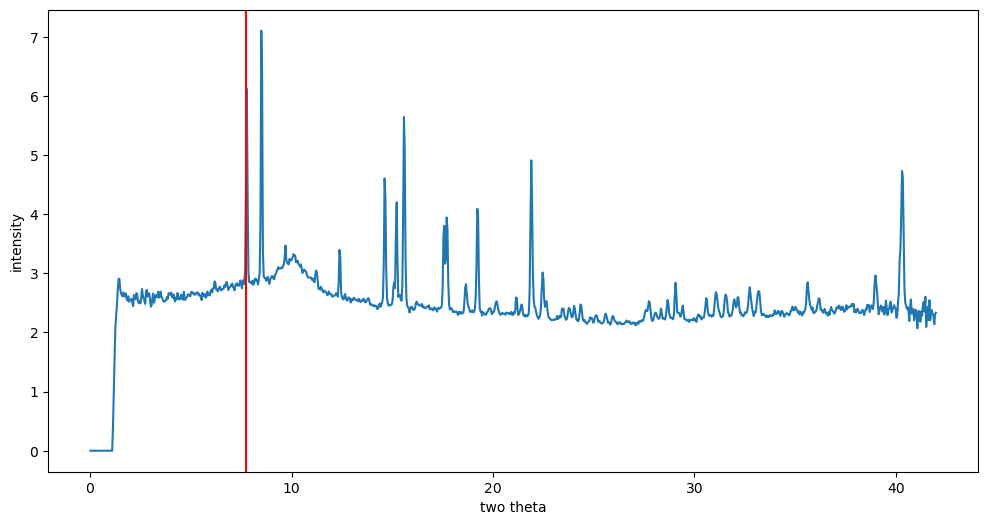

In [42]:
plt.figure(figsize = (12,6))
plt.plot(x, y_inspect)
plt.axvline(7.75, c = 'red')
plt.xlabel('two theta')
plt.ylabel('intensity')
plt.show()

Setting the saving address and file name. Here, the saving architecture is similar from the PROCESSED_DATA experimental data folder, with sample name, then dataset, scanned number. 
<br>
Choose where you want to save your data in the parent_folder.

In [16]:
parent_folder = r"/home/esrf/tran/extracted_data"
saving_address = os.path.join(parent_folder, sample_folder_name)
print(saving_address)
os.makedirs(saving_address, exist_ok = True)

/home/esrf/tran/extracted_data/dq_pap217


In [19]:

#xy = np.column_stack((x, y))
xy = np.column_stack((x, y_cellulose))
#filename = f"{scan_path_name}.xy"
filename = "cellulose.xy"
savepath = os.path.join(saving_address,filename)
np.savetxt(savepath, xy)

NameError: name 'binned_map' is not defined